# In this notebook we will explore the possibility of building and applying a (Bi)GRU to perform the task of classification of the pirate time series dataset.

In [ ]:
#Connect to Google drive
from google.colab import drive
drive.mount("/gdrive")
current_dir = "/gdrive/My Drive/Colab Notebooks/NN/Challenge1"
%cd $current_dir

Mounted at /gdrive
/gdrive/My Drive/Colab Notebooks/NN/Challenge1


import libraries

In [ ]:
# Set seed for reproducibility
SEED = 42

# Import necessary libraries and modules
import os
import time
import warnings
import logging
import random
import numpy as np
import torch
from torch import nn
from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from datetime import datetime

# Suppress warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Set seeds for random number generators in NumPy and Python
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

# Tensorboard setup
logs_dir = "tensorboard"
!pkill -f tensorboard
%load_ext tensorboard
!mkdir -p models # Create directory for saving model weights

# Device setup (GPU/CPU)
if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

# Install torchmetrics
!pip install torchmetrics

PyTorch version: 2.8.0+cu126
Device: cuda
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 57.1 MB/s eta 0:00:00


# Data explainability

In [ ]:
# Read the dataset into a DataFrame with specified column names
data = pd.read_csv('pirate_pain_train.csv', header=0)

In [ ]:
data.head(10) #shows the first ten row of the dataset

,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,n_legs,n_hands,n_eyes,joint_00,...,joint_21,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30
0,0,0,2,0,2,1,two,two,two,1.094705,...,3.499558e-06,1.945042e-06,3.999558e-06,1.153299e-05,0.000004,0.017592,0.013508,0.026798,0.027815,0.5
1,0,1,2,2,2,2,two,two,two,1.135183,...,3.976952e-07,6.765107e-07,6.019627e-06,4.643774e-08,0.000000,0.013352,0.000000,0.013377,0.013716,0.5
2,0,2,2,0,2,2,two,two,two,1.080745,...,1.533820e-07,1.698525e-07,1.446051e-06,2.424536e-06,0.000003,0.016225,0.008110,0.024097,0.023105,0.5
3,0,3,2,2,2,2,two,two,two,0.938017,...,1.006865e-05,5.511079e-07,1.847597e-06,5.432416e-08,0.000000,0.011832,0.007450,0.028613,0.024648,0.5
4,0,4,2,2,2,2,two,two,two,1.090185,...,4.437266e-06,1.735459e-07,1.552722e-06,5.825366e-08,0.000007,0.005360,0.002532,0.033026,0.025328,0.5
5,0,5,2,0,2,1,two,two,two,1.146031,...,1.073167e-06,1.753837e-07,2.957340e-07,6.217311e-08,0.000007,0.006150,0.006444,0.033101,0.023767,0.5
6,0,6,2,1,2,1,two,two,two,1.025870,...,1.074800e-06,1.772156e-07,1.976558e-06,1.576086e-06,0.000005,0.006495,0.006421,0.031804,0.019056,0.5
7,0,7,2,2,2,2,two,two,two,1.038597,...,8.829074e-07,1.790415e-07,2.210562e-06,1.485741e-06,0.000000,0.015998,0.005397,0.035552,0.015732,0.5
8,0,8,2,2,0,1,two,two,two,0.984251,...,1.621055e-06,1.165161e-06,3.030164e-07,5.416678e-07,0.000000,0.020539,0.008517,0.008635,0.015257,0.5
9,0,9,0,2,2,2,two,two,two,1.054999,...,1.609114e-06,3.959558e-06,2.017157e-06,1.154349e-06,0.000007,0.007682,0.021383,0.034006,0.028966,0.5


In [ ]:
#read dataset with labels
label_df=pd.read_csv('pirate_pain_train_labels.csv', header=0)

In [ ]:
label_df.head(10)

,sample_index,label
0,0,no_pain
1,1,no_pain
2,2,low_pain
3,3,no_pain
4,4,no_pain
5,5,no_pain
6,6,no_pain
7,7,no_pain
8,8,no_pain
9,9,no_pain


In [ ]:
#merge labels with dataset
df = data.merge(label_df, on="sample_index", how="left", validate="m:1")

print(df["label"].value_counts())
df.head()

label
no_pain      81760
low_pain     15040
high_pain     8960
Name: count, dtype: int64


,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,n_legs,n_hands,n_eyes,joint_00,...,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30,label
0,0,0,2,0,2,1,two,two,two,1.094705,...,1.945042e-06,0.000004,1.153299e-05,0.000004,0.017592,0.013508,0.026798,0.027815,0.5,no_pain
1,0,1,2,2,2,2,two,two,two,1.135183,...,6.765107e-07,0.000006,4.643774e-08,0.000000,0.013352,0.000000,0.013377,0.013716,0.5,no_pain
2,0,2,2,0,2,2,two,two,two,1.080745,...,1.698525e-07,0.000001,2.424536e-06,0.000003,0.016225,0.008110,0.024097,0.023105,0.5,no_pain
3,0,3,2,2,2,2,two,two,two,0.938017,...,5.511079e-07,0.000002,5.432416e-08,0.000000,0.011832,0.007450,0.028613,0.024648,0.5,no_pain
4,0,4,2,2,2,2,two,two,two,1.090185,...,1.735459e-07,0.000002,5.825366e-08,0.000007,0.005360,0.002532,0.033026,0.025328,0.5,no_pain


In [ ]:
# Counting how many pirates are present in the dataset
print("Pirates:", len(np.unique(df['sample_index'])))

Pirates: 661


In [ ]:
# Print the shape of the DataFrame
print(f"DataFrame shape: {df.shape}")


DataFrame shape: (105760, 41)


In [ ]:
# Display a concise summary of the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105760 entries, 0 to 105759
Data columns (total 41 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   sample_index   105760 non-null  int64  
 1   time           105760 non-null  int64  
 2   pain_survey_1  105760 non-null  int64  
 3   pain_survey_2  105760 non-null  int64  
 4   pain_survey_3  105760 non-null  int64  
 5   pain_survey_4  105760 non-null  int64  
 6   n_legs         105760 non-null  object 
 7   n_hands        105760 non-null  object 
 8   n_eyes         105760 non-null  object 
 9   joint_00       105760 non-null  float64
 10  joint_01       105760 non-null  float64
 11  joint_02       105760 non-null  float64
 12  joint_03       105760 non-null  float64
 13  joint_04       105760 non-null  float64
 14  joint_05       105760 non-null  float64
 15  joint_06       105760 non-null  float64
 16  joint_07       105760 non-null  float64
 17  joint_08       105760 non-nul

In [ ]:
#convert to float32
df[df.select_dtypes(include=[np.number]).columns] = df.select_dtypes(include=[np.number]).astype(np.float32)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105760 entries, 0 to 105759
Data columns (total 41 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   sample_index   105760 non-null  float32
 1   time           105760 non-null  float32
 2   pain_survey_1  105760 non-null  float32
 3   pain_survey_2  105760 non-null  float32
 4   pain_survey_3  105760 non-null  float32
 5   pain_survey_4  105760 non-null  float32
 6   n_legs         105760 non-null  object 
 7   n_hands        105760 non-null  object 
 8   n_eyes         105760 non-null  object 
 9   joint_00       105760 non-null  float32
 10  joint_01       105760 non-null  float32
 11  joint_02       105760 non-null  float32
 12  joint_03       105760 non-null  float32
 13  joint_04       105760 non-null  float32
 14  joint_05       105760 non-null  float32
 15  joint_06       105760 non-null  float32
 16  joint_07       105760 non-null  float32
 17  joint_08       105760 non-nul

In [ ]:
#show a row for each pirate
first_rows_per_sample = (
    df.drop_duplicates(subset="sample_index", keep="first")
      .head(10)
      .reset_index(drop=True)
)

first_rows_per_sample


,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,n_legs,n_hands,n_eyes,joint_00,...,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30,label
0,0.0,0.0,2.0,0.0,2.0,1.0,two,two,two,1.094705,...,1.945042e-06,3.999558e-06,1.153299e-05,3.805930e-06,0.017592,0.013508,0.026798,0.027815,0.5,no_pain
1,1.0,0.0,2.0,1.0,2.0,2.0,two,two,two,1.233603,...,1.790415e-07,3.006389e-07,6.997916e-08,0.000000e+00,0.038205,0.071314,0.167005,0.071224,0.5,no_pain
2,2.0,0.0,1.0,1.0,1.0,2.0,two,two,two,0.170677,...,1.183228e-06,2.236364e-06,9.688514e-08,5.987389e-07,0.193762,0.115937,0.039989,0.032033,0.5,low_pain
3,3.0,0.0,1.0,2.0,2.0,0.0,two,two,two,0.996243,...,1.802904e-06,2.588236e-06,1.715739e-06,5.349919e-06,0.017648,0.044323,0.045728,0.041061,0.5,no_pain
4,4.0,0.0,2.0,2.0,0.0,0.0,two,two,two,0.972103,...,2.407151e-06,1.974214e-06,8.159604e-08,0.000000e+00,0.002939,0.015767,0.017016,0.021965,0.5,no_pain
5,5.0,0.0,2.0,0.0,2.0,2.0,two,two,two,1.126637,...,1.661360e-07,2.826171e-07,4.248218e-08,6.992469e-06,0.014098,0.051534,0.012429,0.051722,0.5,no_pain
6,6.0,0.0,2.0,0.0,2.0,2.0,two,two,two,1.101345,...,9.419276e-07,3.239535e-07,8.933957e-07,0.000000e+00,0.027001,0.144871,0.044796,0.037567,0.5,no_pain
7,7.0,0.0,2.0,2.0,2.0,2.0,two,two,two,1.072391,...,1.772156e-07,2.982113e-07,6.608183e-08,0.000000e+00,0.027947,0.070982,0.027583,0.015155,0.5,no_pain
8,8.0,0.0,2.0,2.0,2.0,2.0,one+peg_leg,one+hook_hand,one+eye_patch,1.044719,...,6.372409e-07,4.913076e-07,1.275396e-06,1.013391e-04,0.006518,0.009533,0.021116,0.036020,0.5,no_pain
9,9.0,0.0,2.0,0.0,2.0,2.0,two,two,two,0.987456,...,1.803519e-07,2.622896e-07,1.462642e-08,3.784606e-06,0.005788,0.009742,0.012155,0.014311,0.5,no_pain


In [ ]:
#which are the values of categorical feature?
print(df["n_legs"].astype(str).str.strip().str.lower().unique())
print(df["n_hands"].astype(str).str.strip().str.lower().unique())
print(df["n_eyes"].astype(str).str.strip().str.lower().unique())


['two' 'one+peg_leg']
['two' 'one+hook_hand']
['two' 'one+eye_patch']


In [ ]:
#convert to numerical
df[["n_legs","n_hands","n_eyes"]] = (
    df[["n_legs","n_hands","n_eyes"]]
      .apply(lambda s: s.astype(str).str.strip().str.lower())
)


count_map = {"two": 2, "one+peg_leg": 1, "one+hook_hand": 1, "one+eye_patch": 1}

df["legs_count"]  = df["n_legs"].map(count_map).astype("float32")
df["hands_count"] = df["n_hands"].map(count_map).astype("float32")
df["eyes_count"]  = df["n_eyes"].map(count_map).astype("float32")

df["leg_prosthetic"] = (df["n_legs"]  != "two").astype("float32")
df["hand_hook"]      = (df["n_hands"] != "two").astype("float32")
df["eye_patch"]      = (df["n_eyes"]  != "two").astype("float32")

df_enc = df.drop(columns=["n_legs","n_hands","n_eyes"])



In [ ]:
#show convertion
first_rows_per_sample = (
    df_enc.drop_duplicates(subset="sample_index", keep="first")
      .head(10)
      .reset_index(drop=True)
)

first_rows_per_sample

,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,joint_00,joint_01,joint_02,joint_03,...,joint_28,joint_29,joint_30,label,legs_count,hands_count,eyes_count,leg_prosthetic,hand_hook,eye_patch
0,0.0,0.0,2.0,0.0,2.0,1.0,1.094705,0.985281,1.018302,1.010385,...,0.026798,0.027815,0.5,no_pain,2.0,2.0,2.0,0.0,0.0,0.0
1,1.0,0.0,2.0,1.0,2.0,2.0,1.233603,1.029888,1.151819,0.964590,...,0.167005,0.071224,0.5,no_pain,2.0,2.0,2.0,0.0,0.0,0.0
2,2.0,0.0,1.0,1.0,1.0,2.0,0.170677,0.000000,0.150608,0.441534,...,0.039989,0.032033,0.5,low_pain,2.0,2.0,2.0,0.0,0.0,0.0
3,3.0,0.0,1.0,2.0,2.0,0.0,0.996243,1.078399,0.932990,0.998395,...,0.045728,0.041061,0.5,no_pain,2.0,2.0,2.0,0.0,0.0,0.0
4,4.0,0.0,2.0,2.0,0.0,0.0,0.972103,0.941107,0.988553,0.934516,...,0.017016,0.021965,0.5,no_pain,2.0,2.0,2.0,0.0,0.0,0.0
5,5.0,0.0,2.0,0.0,2.0,2.0,1.126637,1.038498,0.938397,0.899024,...,0.012429,0.051722,0.5,no_pain,2.0,2.0,2.0,0.0,0.0,0.0
6,6.0,0.0,2.0,0.0,2.0,2.0,1.101345,1.025400,0.942634,0.965327,...,0.044796,0.037567,0.5,no_pain,2.0,2.0,2.0,0.0,0.0,0.0
7,7.0,0.0,2.0,2.0,2.0,2.0,1.072391,0.988676,1.015451,0.891076,...,0.027583,0.015155,0.5,no_pain,2.0,2.0,2.0,0.0,0.0,0.0
8,8.0,0.0,2.0,2.0,2.0,2.0,1.044719,1.033696,1.022788,0.967894,...,0.021116,0.036020,0.5,no_pain,1.0,1.0,1.0,1.0,1.0,1.0
9,9.0,0.0,2.0,0.0,2.0,2.0,0.987456,0.939778,0.845851,0.924030,...,0.012155,0.014311,0.5,no_pain,2.0,2.0,2.0,0.0,0.0,0.0


In [ ]:
df_enc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105760 entries, 0 to 105759
Data columns (total 44 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   sample_index    105760 non-null  float32
 1   time            105760 non-null  float32
 2   pain_survey_1   105760 non-null  float32
 3   pain_survey_2   105760 non-null  float32
 4   pain_survey_3   105760 non-null  float32
 5   pain_survey_4   105760 non-null  float32
 6   joint_00        105760 non-null  float32
 7   joint_01        105760 non-null  float32
 8   joint_02        105760 non-null  float32
 9   joint_03        105760 non-null  float32
 10  joint_04        105760 non-null  float32
 11  joint_05        105760 non-null  float32
 12  joint_06        105760 non-null  float32
 13  joint_07        105760 non-null  float32
 14  joint_08        105760 non-null  float32
 15  joint_09        105760 non-null  float32
 16  joint_10        105760 non-null  float32
 17  joint_11  

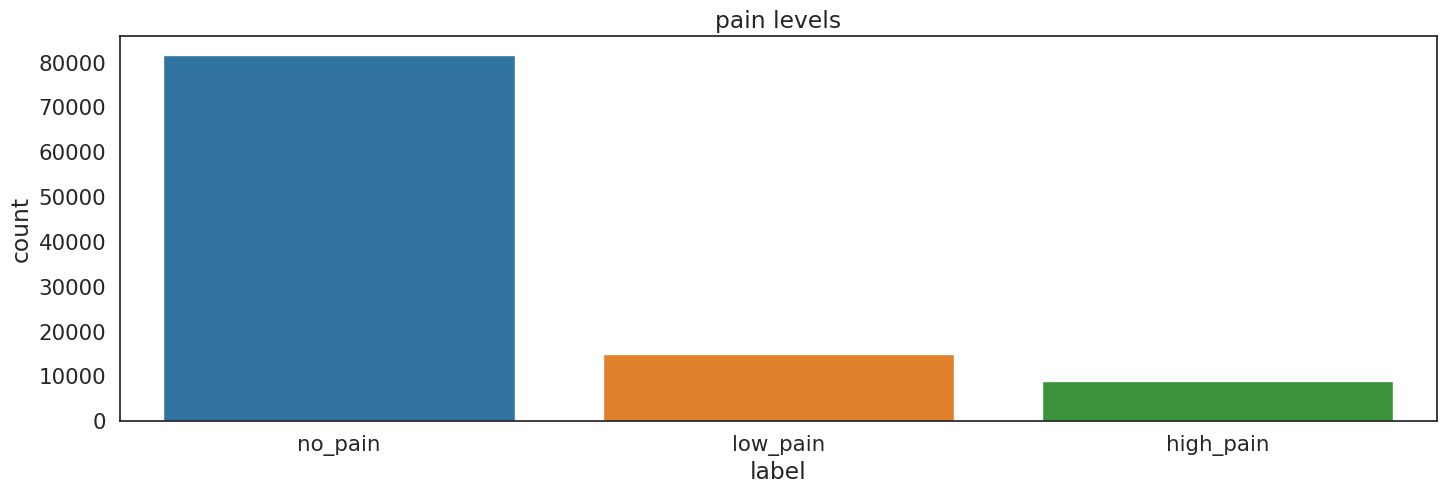

In [ ]:
# Visualise the count of timestamps for each pain level
plt.figure(figsize=(17, 5))
sns.countplot(
    x='label',
    data=df_enc,
    order=df_enc['label'].value_counts().index,
    palette='tab10'
)

# Set the title of the plot
plt.title('pain levels')

# Display the plot
plt.show()

In [ ]:
# count timestamp for each sample_index
per_user_counts = (
    df_enc["sample_index"]
    .value_counts()
    .sort_index()
)


per_user_df = (
    per_user_counts
    .sort_values(ascending=False)
    .rename_axis("sample_index")
    .reset_index(name="n_timestamps")
)

print(per_user_df.head(30))       # show some
print(len(per_user_df), "number of pirates")

    sample_index  n_timestamps
0          660.0           160
1            0.0           160
2            1.0           160
3            2.0           160
4            3.0           160
5            4.0           160
6            5.0           160
7            6.0           160
8            7.0           160
9            8.0           160
10           9.0           160
11          10.0           160
12          11.0           160
13          12.0           160
14          13.0           160
15          14.0           160
16          15.0           160
17          16.0           160
18          17.0           160
19          18.0           160
20          19.0           160
21         621.0           160
22         622.0           160
23         623.0           160
24         624.0           160
25         625.0           160
26         626.0           160
27         627.0           160
28         628.0           160
29         613.0           160
661 number of pirates


In [ ]:
# Define a function to inspect one joint for a specific pain
def inspect_joint(label, df):
    # Filter the DataFrame for the specified activity and limit to 100 rows
    data = df[df['label'] == label][['joint_01']][:100]

    # Plot the sensor data for each axis
    axis = data.plot(subplots=True, figsize=(17, 9), title=label)

    # Adjust legend position for each subplot
    for ax in axis:
        ax.legend(loc='lower right')

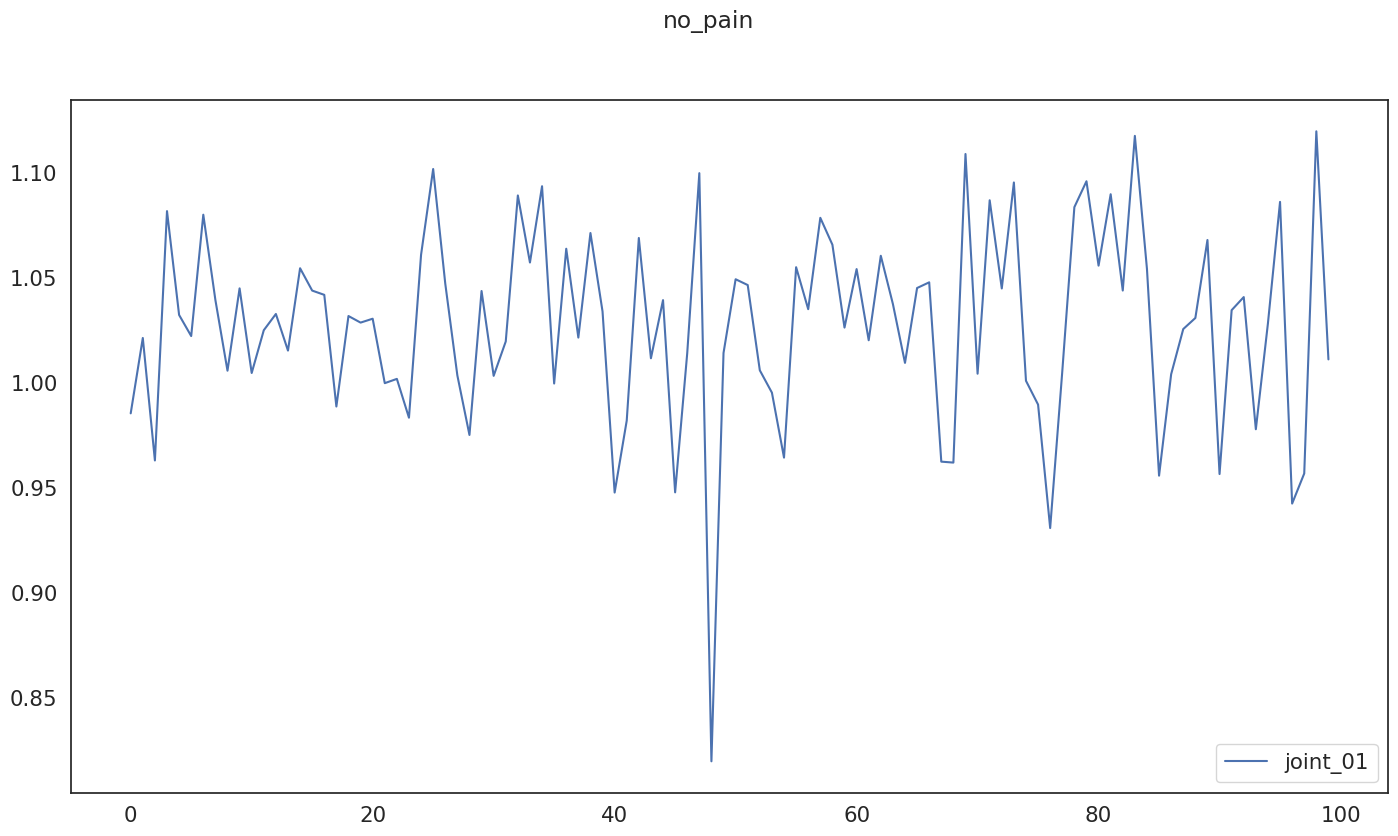

In [ ]:
# Inspect the sensor data for the joint 1"
inspect_joint("no_pain", df_enc)

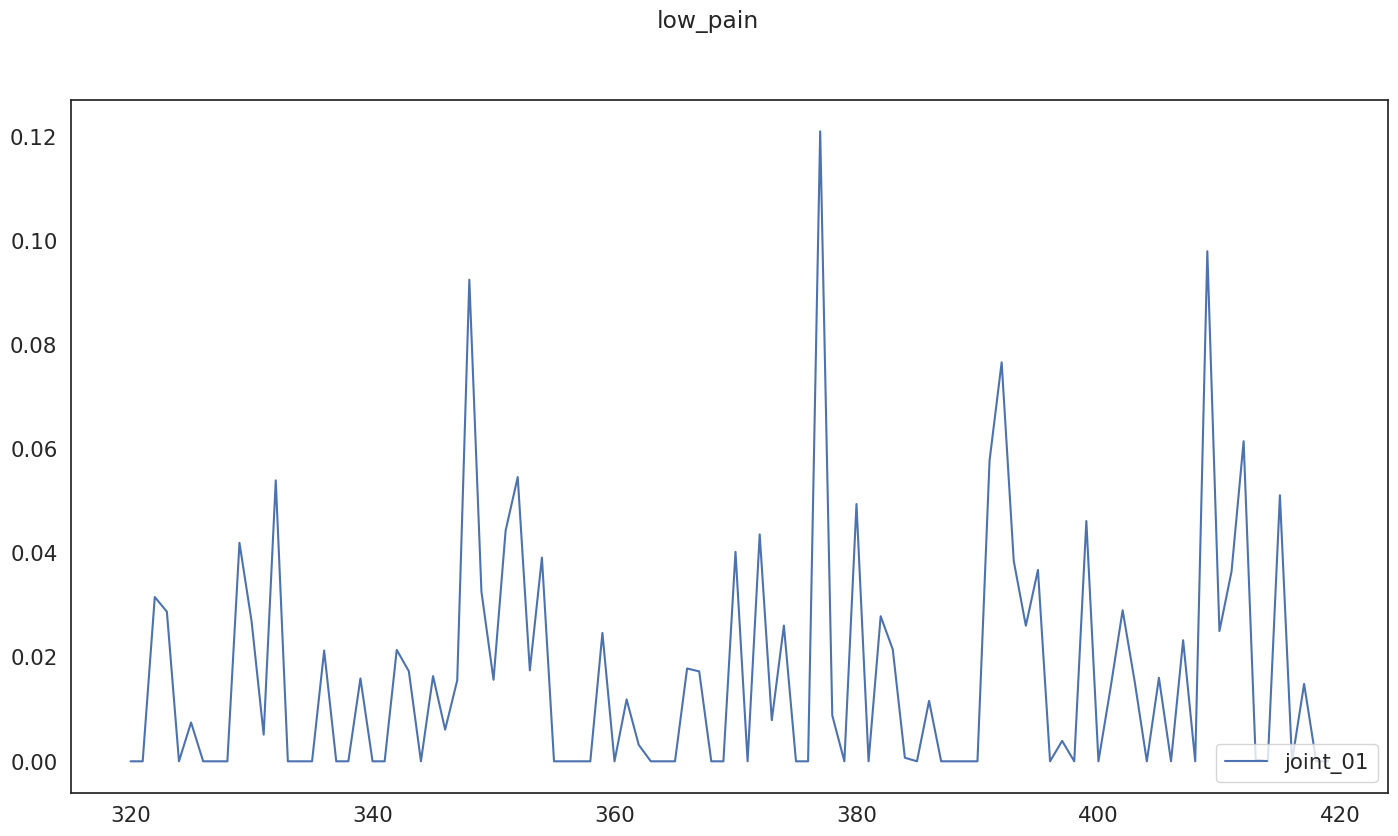

In [ ]:

inspect_joint("low_pain", df_enc)

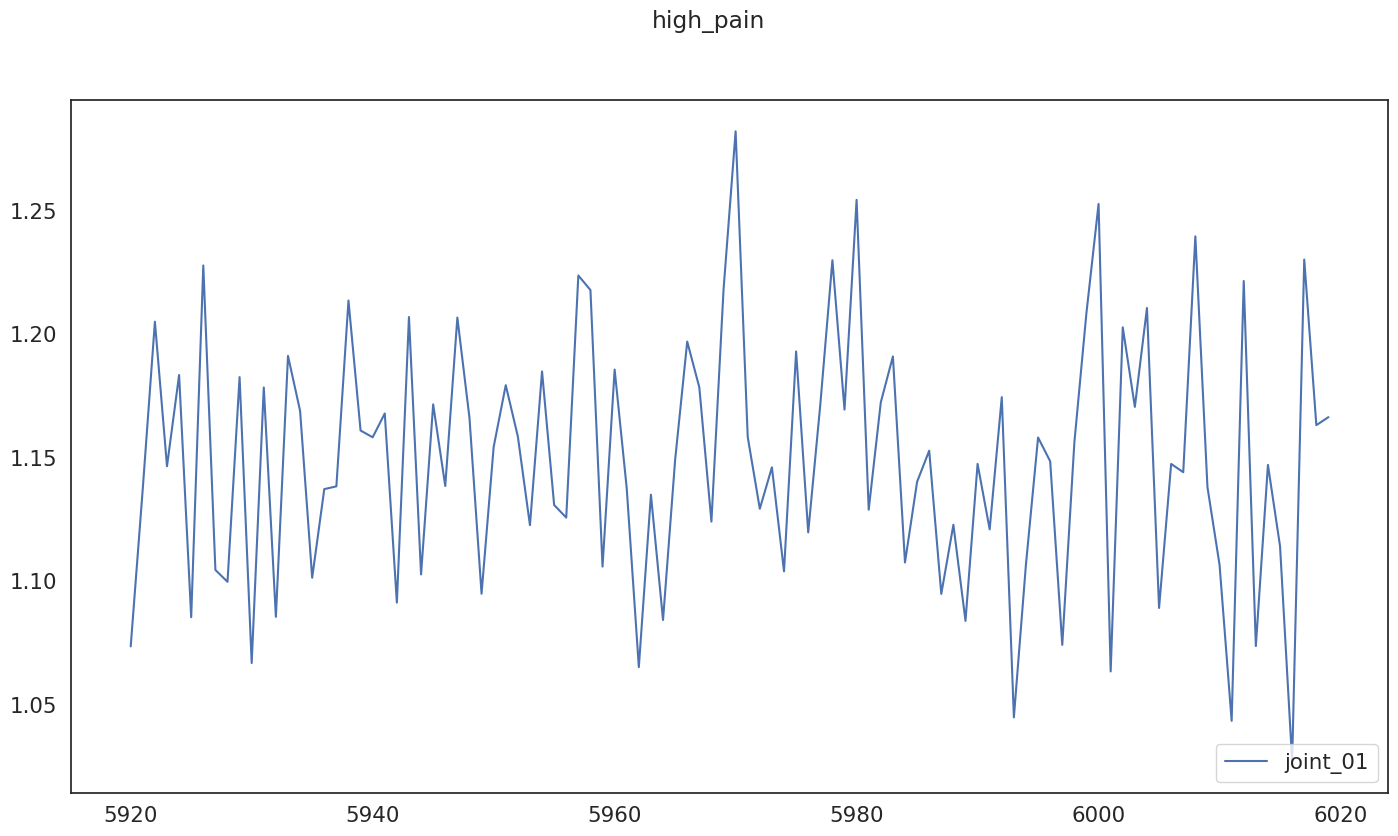

In [ ]:

inspect_joint("high_pain", df_enc)

In [ ]:
#split into train, validation and test sets
from sklearn.model_selection import train_test_split


N_VAL_USERS  = 99
N_TEST_USERS = 99
SEED = 42

per_user = (
    df_enc.drop_duplicates("sample_index")[["sample_index", "label"]]
           .rename(columns={"sample_index": "user", "label": "y"})
)
ids    = per_user["user"].to_numpy()
labels = per_user["y"].to_numpy()



trainval_ids, test_ids, y_trainval, y_test = train_test_split(
    ids, labels,
    test_size=N_TEST_USERS,
    stratify=labels,
    random_state=SEED,
)


train_ids, val_ids, y_train, y_val = train_test_split(
    trainval_ids, y_trainval,
    test_size=N_VAL_USERS,
    stratify=y_trainval,
    random_state=SEED,
)


df_train = df_enc[df_enc["sample_index"].isin(train_ids)].copy()
df_val   = df_enc[df_enc["sample_index"].isin(val_ids)].copy()
df_test  = df_enc[df_enc["sample_index"].isin(test_ids)].copy()

print("Train:", df_train.shape, "Val:", df_val.shape, "Test:", df_test.shape)


def dist_per_user(d):
    return d.drop_duplicates("sample_index")["label"].value_counts().sort_index().to_dict()

print("Distribuzione utenti per classe:")
print("  Train:", dist_per_user(df_train))
print("  Val  :", dist_per_user(df_val))
print("  Test :", dist_per_user(df_test))



Train: (74080, 44) Val: (15840, 44) Test: (15840, 44)
Distribuzione utenti per classe:
  Train: {'high_pain': 39, 'low_pain': 66, 'no_pain': 358}
  Val  : {'high_pain': 9, 'low_pain': 14, 'no_pain': 76}
  Test : {'high_pain': 8, 'low_pain': 14, 'no_pain': 77}


In [ ]:
#show counts in train
per_patient = df_train.drop_duplicates("sample_index")[["sample_index","label"]]
counts = per_patient["label"].value_counts().reindex(["no_pain","low_pain","high_pain"], fill_value=0)
print(counts.to_dict())


{'no_pain': 358, 'low_pain': 66, 'high_pain': 39}


In [ ]:
#in val
per_patient = df_val.drop_duplicates("sample_index")[["sample_index","label"]]
counts = per_patient["label"].value_counts().reindex(["no_pain","low_pain","high_pain"], fill_value=0)
print(counts.to_dict())

{'no_pain': 76, 'low_pain': 14, 'high_pain': 9}


In [ ]:
# in test
per_patient = df_test.drop_duplicates("sample_index")[["sample_index","label"]]
counts = per_patient["label"].value_counts().reindex(["no_pain","low_pain","high_pain"], fill_value=0)
print(counts.to_dict())

{'no_pain': 77, 'low_pain': 14, 'high_pain': 8}


In [ ]:
#map labels--> also label numericals
class_order = ["no_pain", "low_pain", "high_pain"]
label_map = {c: i for i, c in enumerate(class_order)}

for d in (df_train, df_val, df_test):

    d["label"] = d["label"].map(label_map).astype("int8")


In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 74080 entries, 0 to 105759
Data columns (total 44 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sample_index    74080 non-null  float32
 1   time            74080 non-null  float32
 2   pain_survey_1   74080 non-null  float32
 3   pain_survey_2   74080 non-null  float32
 4   pain_survey_3   74080 non-null  float32
 5   pain_survey_4   74080 non-null  float32
 6   joint_00        74080 non-null  float32
 7   joint_01        74080 non-null  float32
 8   joint_02        74080 non-null  float32
 9   joint_03        74080 non-null  float32
 10  joint_04        74080 non-null  float32
 11  joint_05        74080 non-null  float32
 12  joint_06        74080 non-null  float32
 13  joint_07        74080 non-null  float32
 14  joint_08        74080 non-null  float32
 15  joint_09        74080 non-null  float32
 16  joint_10        74080 non-null  float32
 17  joint_11        74080 non-null  flo

In [ ]:
import numpy as np

# exlude this from normalization
exclude = ["sample_index", "time","label"]


scale_columns = [c for c in df_train.columns if c not in exclude]

#  min e max on training set
mins = df_train[scale_columns].min()
ranges = (df_train[scale_columns].max() - mins).replace(0, 1.0)

# apply min–max (0–1)
for df_ in (df_train, df_val, df_test):
    df_[scale_columns] = (df_[scale_columns] - mins) / ranges


In [ ]:
# Display the first five rows of the training DataFrame
print(df_train["label"].value_counts())
df_train.head()

label
0    57280
1    10560
2     6240
Name: count, dtype: int64


,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,joint_00,joint_01,joint_02,joint_03,...,joint_28,joint_29,joint_30,label,legs_count,hands_count,eyes_count,leg_prosthetic,hand_hook,eye_patch
0,0.0,0.0,1.0,0.0,1.0,0.5,0.777046,0.738252,0.779512,0.804411,...,0.018978,0.020291,0.0,0,1.0,1.0,1.0,0.0,0.0,0.0
1,0.0,1.0,1.0,1.0,1.0,1.0,0.805855,0.765147,0.761153,0.838014,...,0.009473,0.010006,0.0,0,1.0,1.0,1.0,0.0,0.0,0.0
2,0.0,2.0,1.0,0.0,1.0,1.0,0.767110,0.721439,0.772834,0.777823,...,0.017065,0.016856,0.0,0,1.0,1.0,1.0,0.0,0.0,0.0
3,0.0,3.0,1.0,1.0,1.0,1.0,0.665528,0.810416,0.763971,0.785919,...,0.020264,0.017981,0.0,0,1.0,1.0,1.0,0.0,0.0,0.0
4,0.0,4.0,1.0,1.0,1.0,1.0,0.773829,0.773366,0.772162,0.767008,...,0.023389,0.018477,0.0,0,1.0,1.0,1.0,0.0,0.0,0.0


In [ ]:
# Define the window size
WINDOW_SIZE = 160 #model will se 160 timestamp each time= 1 window for every pirate

#since our window is as long as the sequence for a single patient we don't use a stride

In [ ]:
import numpy as np
import pandas as pd

def build_sequence(
    df: pd.DataFrame,
    label_col="label",
    id_col="sample_index",
    time_col="time",
    feature_cols=None,
    window=160,
    pad_value=0.0,
    pad_side="end",
):

    # Select numeric feature columns (exclude id, time, and label)
    if feature_cols is None:
        exclude = {id_col, time_col, label_col}
        feature_cols = [
            c for c in df.select_dtypes(include=[np.number]).columns
            if c not in exclude
        ]

    sequences, labels = [], []

    # Iterate over each subject or sample
    for pid, g in df.groupby(id_col):
        # Sort by time to ensure temporal order
        g = g.sort_values(time_col, kind="stable")

        # Extract features as NumPy array
        X = g[feature_cols].to_numpy(dtype=np.float32)

        # Extract the label (one per subject)
        y_vals = g[label_col].dropna().unique()
        y = y_vals[0] if len(y_vals) > 0 else np.nan

        # If the sequence is shorter than the window → pad
        if len(X) < window:
            pad_len = window - len(X)
            pad_block = np.full((pad_len, X.shape[1]), pad_value, dtype=np.float32)
            X = np.vstack([pad_block, X]) if pad_side == "start" else np.vstack([X, pad_block])

        # If the sequence is longer than the window → truncate
        elif len(X) > window:
            X = X[:window]

        # Store the processed sequence and label
        sequences.append(X)
        labels.append(y)

    return np.asarray(sequences, dtype=np.float32), np.asarray(labels)


In [ ]:

feature_cols = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if c not in ["sample_index", "time"]  # escludi ID e tempo
]

X_seq, y_seq = build_sequence(
    df,
    label_col="label",
    id_col="sample_index",
    time_col="time",
    feature_cols=feature_cols,
    window=160,
    pad_value=0.0,
    pad_side="end",
)

print(X_seq.shape)  # (n_windows, window, n_features)
print(y_seq.shape)  # (n_windows,)

(661, 160, 41)
(661,)


In [ ]:
# generate sequence for every set
X_train, y_train = build_sequence(
    df=df_train,
    window=WINDOW_SIZE,

)

X_val, y_val = build_sequence(
    df=df_val,
    window=WINDOW_SIZE,

)

X_test, y_test = build_sequence(
    df=df_test,
    window=WINDOW_SIZE,

)

print(
    X_train.shape, y_train.shape,
    X_val.shape, y_val.shape,
    X_test.shape, y_test.shape
)


(463, 160, 41) (463,) (99, 160, 41) (99,) (99, 160, 41) (99,)


In [ ]:
# Define the input shape based on the training data
input_shape = X_train.shape[1:]

# Define the number of classes based on the categorical labels
num_classes = len(np.unique(y_train))

In [ ]:
X_train.shape[1:]

(160, 41)

In [ ]:
# Convert numpy arrays to PyTorch datasets (pairs features with labels)
train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
val_ds   = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val))
test_ds  = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test))

In [ ]:
# Define the batch size, which is the number of samples in each batch
BATCH_SIZE = 124

In [ ]:
def make_loader(ds, batch_size, shuffle, drop_last):
    # Determine optimal number of worker processes for data loading
    cpu_cores = os.cpu_count() or 2
    num_workers = max(2, min(4, cpu_cores))

    # Create DataLoader with performance optimizations
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers,
        pin_memory=True,  # Faster GPU transfer
        pin_memory_device="cuda" if torch.cuda.is_available() else "",
        prefetch_factor=4,  # Load 4 batches ahead
    )

In [ ]:
# Create data loaders with different settings for each phase
train_loader = make_loader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader   = make_loader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader  = make_loader(test_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

In [ ]:
# Get one batch from the training data loader
for xb, yb in train_loader:
    print("Features batch shape:", xb.shape)
    print("Labels batch shape:", yb.shape)
    break # Stop after getting one batch

Features batch shape: torch.Size([124, 160, 41])
Labels batch shape: torch.Size([124])


In [ ]:
import os, json
import numpy as np
import pandas as pd

def save_all(
    out_dir,
    df_train, df_val, df_test,
    X_train, y_train, X_val, y_val, X_test, y_test,
    mins, ranges, feature_cols,
    class_order=("no_pain","low_pain","high_pain"),
    y_dtype_np="int32"
):
    os.makedirs(out_dir, exist_ok=True)

    # 1) DataFrame preprocessed
    df_train.to_parquet(os.path.join(out_dir, "train_preprocessed.parquet"), index=False)
    df_val.to_parquet(  os.path.join(out_dir, "val_preprocessed.parquet"),   index=False)
    df_test.to_parquet( os.path.join(out_dir, "test_preprocessed.parquet"),  index=False)

    # 2) Parameters (fit su train)
    norm_info = {
        "scale_columns": list(mins.index),
        "mins":   {k: float(v) for k, v in mins.to_dict().items()},
        "ranges": {k: float(v) for k, v in ranges.to_dict().items()},
    }
    with open(os.path.join(out_dir, "normalization.json"), "w") as f:
        json.dump(norm_info, f, indent=2)

    # 3) Map classes
    with open(os.path.join(out_dir, "class_map.json"), "w") as f:
        json.dump({"class_order": list(class_order)}, f, indent=2)

    # 4) Features
    with open(os.path.join(out_dir, "feature_cols.json"), "w") as f:
        json.dump({"feature_cols": list(feature_cols)}, f, indent=2)

    # 5) Sequenze (NPZ compresso)
    np.savez_compressed(
        os.path.join(out_dir, "train_sequences.npz"),
        X=X_train.astype(np.float32),
        y=y_train.astype(y_dtype_np)
    )
    np.savez_compressed(
        os.path.join(out_dir, "val_sequences.npz"),
        X=X_val.astype(np.float32),
        y=y_val.astype(y_dtype_np)
    )
    np.savez_compressed(
        os.path.join(out_dir, "test_sequences.npz"),
        X=X_test.astype(np.float32),
        y=y_test.astype(y_dtype_np)
    )

    print(f"All saved: {out_dir}")

#actual save
out_dir = "code"

save_all(
    out_dir=out_dir,
    df_train=df_train, df_val=df_val, df_test=df_test,
    X_train=X_train, y_train=y_train,
    X_val=X_val,     y_val=y_val,
    X_test=X_test,   y_test=y_test,
    mins=mins, ranges=ranges,
    feature_cols=feature_cols,
    class_order=("no_pain","low_pain","high_pain"),
    y_dtype_np="int32"
)


All saved: code


# Model development

In [ ]:
def recurrent_summary(model, input_size):
    """
    Custom summary function that emulates torchinfo's output while correctly
    counting parameters for RNN/GRU/LSTM layers.

    This function is designed for models whose direct children are
    nn.Linear, nn.RNN, nn.GRU, or nn.LSTM layers.

    Args:
        model (nn.Module): The model to analyze.
        input_size (tuple): Shape of the input tensor (e.g., (seq_len, features)).
    """

    # Dictionary to store output shapes captured by forward hooks
    output_shapes = {}
    # List to track hook handles for later removal
    hooks = []

    def get_hook(name):
        """Factory function to create a forward hook for a specific module."""
        def hook(module, input, output):
            # Handle RNN layer outputs (returns a tuple)
            if isinstance(output, tuple):
                # output[0]: all hidden states with shape (batch, seq_len, hidden*directions)
                shape1 = list(output[0].shape)
                shape1[0] = -1  # Replace batch dimension with -1

                # output[1]: final hidden state h_n (or tuple (h_n, c_n) for LSTM)
                if isinstance(output[1], tuple):  # LSTM case: (h_n, c_n)
                    shape2 = list(output[1][0].shape)  # Extract h_n only
                else:  # RNN/GRU case: h_n only
                    shape2 = list(output[1].shape)

                # Replace batch dimension (middle position) with -1
                shape2[1] = -1

                output_shapes[name] = f"[{shape1}, {shape2}]"

            # Handle standard layer outputs (e.g., Linear)
            else:
                shape = list(output.shape)
                shape[0] = -1  # Replace batch dimension with -1
                output_shapes[name] = f"{shape}"
        return hook

    # 1. Determine the device where model parameters reside
    try:
        device = next(model.parameters()).device
    except StopIteration:
        device = torch.device("cpu")  # Fallback for models without parameters

    # 2. Create a dummy input tensor with batch_size=1
    dummy_input = torch.randn(1, *input_size).to(device)

    # 3. Register forward hooks on target layers
    # Iterate through direct children of the model (e.g., self.rnn, self.classifier)
    for name, module in model.named_children():
        if isinstance(module, (nn.Linear, nn.RNN, nn.GRU, nn.LSTM)):
            # Register the hook and store its handle for cleanup
            hook_handle = module.register_forward_hook(get_hook(name))
            hooks.append(hook_handle)

    # 4. Execute a dummy forward pass in evaluation mode
    model.eval()
    with torch.no_grad():
        try:
            model(dummy_input)
        except Exception as e:
            print(f"Error during dummy forward pass: {e}")
            # Clean up hooks even if an error occurs
            for h in hooks:
                h.remove()
            return

    # 5. Remove all registered hooks
    for h in hooks:
        h.remove()

    # --- 6. Print the summary table ---

    print("-" * 79)
    # Column headers
    print(f"{'Layer (type)':<25} {'Output Shape':<28} {'Param #':<18}")
    print("=" * 79)

    total_params = 0
    total_trainable_params = 0

    # Iterate through modules again to collect and display parameter information
    for name, module in model.named_children():
        if name in output_shapes:
            # Count total and trainable parameters for this module
            module_params = sum(p.numel() for p in module.parameters())
            trainable_params = sum(p.numel() for p in module.parameters() if p.requires_grad)

            total_params += module_params
            total_trainable_params += trainable_params

            # Format strings for display
            layer_name = f"{name} ({type(module).__name__})"
            output_shape_str = str(output_shapes[name])
            params_str = f"{trainable_params:,}"

            print(f"{layer_name:<25} {output_shape_str:<28} {params_str:<15}")

    print("=" * 79)
    print(f"Total params: {total_params:,}")
    print(f"Trainable params: {total_trainable_params:,}")
    print(f"Non-trainable params: {total_params - total_trainable_params:,}")
    print("-" * 79)

In [ ]:
class RecurrentClassifier(nn.Module):
    """
    Generic RNN classifier (RNN, LSTM, GRU).
    Uses the last hidden state for classification.
    """
    def __init__(
            self,
            input_size,
            hidden_size,
            num_layers,
            num_classes,
            rnn_type='GRU',        # 'RNN', 'LSTM', or 'GRU'
            bidirectional=True,
            dropout_rate=0.2
            ):
        super().__init__()

        self.rnn_type = rnn_type
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.bidirectional = bidirectional

        # Map string name to PyTorch RNN class
        rnn_map = {
            'RNN': nn.RNN,
            'LSTM': nn.LSTM,
            'GRU': nn.GRU
        } #i can do this becasue this network are already implemented in pythorch

        if rnn_type not in rnn_map:
            raise ValueError("rnn_type must be 'RNN', 'LSTM', or 'GRU'")

        rnn_module = rnn_map[rnn_type]

        # Dropout is only applied between layers (if num_layers > 1)
        dropout_val = dropout_rate if num_layers > 1 else 0

        # Create the recurrent layer
        self.rnn = rnn_module(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,       # Input shape: (batch, seq_len, features)
            bidirectional=bidirectional,
            dropout=dropout_val
        )

        # Calculate input size for the final classifier
        if self.bidirectional:
            classifier_input_size = hidden_size * 2 # Concat fwd + bwd
        else:
            classifier_input_size = hidden_size

        # Final classification layer
        self.classifier = nn.Linear(classifier_input_size, num_classes)

    def forward(self, x):
        """
        x shape: (batch_size, seq_length, input_size)
        """

        # rnn_out shape: (batch_size, seq_len, hidden_size * num_directions)
        rnn_out, hidden = self.rnn(x) #2 outputs

        # LSTM returns (h_n, c_n), we only need h_n
        if self.rnn_type == 'LSTM':
            hidden = hidden[0] #2 types of hidden state (also cell state) but we are intrested only on the hidden state

        # hidden shape: (num_layers * num_directions, batch_size, hidden_size)

        if self.bidirectional:
            # Reshape to (num_layers, 2, batch_size, hidden_size)
            hidden = hidden.view(self.num_layers, 2, -1, self.hidden_size)

            # Concat last fwd (hidden[-1, 0, ...]) and bwd (hidden[-1, 1, ...])
            # Final shape: (batch_size, hidden_size * 2)
            hidden_to_classify = torch.cat([hidden[-1, 0, :, :], hidden[-1, 1, :, :]], dim=1)
        else:
            # Take the last layer's hidden state
            # Final shape: (batch_size, hidden_size)
            hidden_to_classify = hidden[-1]  #last state, what we are intrested in

        # Get logits
        logits = self.classifier(hidden_to_classify)
        return logits


In [ ]:
# Training configuration
LEARNING_RATE = 1e-3
EPOCHS = 200
PATIENCE = 50

# Architecture
HIDDEN_LAYERS = 2        # Hidden layers
HIDDEN_SIZE = 128        # Neurons per layer

# Regularisation
DROPOUT_RATE = 0.2         # Dropout probability
L1_LAMBDA = 0            # L1 penalty
L2_LAMBDA = 0            # L2 penalty

# Set up loss function and optimizer, loss function
criterion = nn.CrossEntropyLoss()

In [ ]:
# Initialize best model tracking variables
best_model = None
best_performance = float('-inf')

In [ ]:
def train_one_epoch(model, train_loader, criterion, optimizer, scaler, device, l1_lambda=0, l2_lambda=0):

    model.train()  # Set model to training mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Iterate through training batches
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        # Move data to device (GPU/CPU)
        inputs  = inputs.to(device).float()   # (N, T, F) float32
        targets = targets.to(device).long()

        # Clear gradients from previous step
        optimizer.zero_grad(set_to_none=True)

        # Forward pass with mixed precision (if CUDA available)
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
            logits = model(inputs)
            loss = criterion(logits, targets)

            # Add L1 and L2 regularization
            l1_norm = sum(p.abs().sum() for p in model.parameters())
            l2_norm = sum(p.pow(2).sum() for p in model.parameters())
            loss = loss + l1_lambda * l1_norm + l2_lambda * l2_norm


        # Backward pass with gradient scaling
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Accumulate metrics
        running_loss += loss.item() * inputs.size(0)
        predictions = logits.argmax(dim=1)
        all_predictions.append(predictions.cpu().numpy())
        all_targets.append(targets.cpu().numpy())

    # Calculate epoch metrics
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_f1 = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_f1

In [ ]:
def validate_one_epoch(model, val_loader, criterion, device):

    model.eval()  # Set model to evaluation mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Disable gradient computation for validation
    with torch.no_grad():
        for inputs, targets in val_loader:
            # Move data to device
            inputs  = inputs.to(device).float()   # (N, T, F) float32
            targets = targets.to(device).long()

            # Forward pass with mixed precision (if CUDA available)
            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logits = model(inputs)
                loss = criterion(logits, targets)

            # Accumulate metrics
            running_loss += loss.item() * inputs.size(0)
            predictions = logits.argmax(dim=1)
            all_predictions.append(predictions.cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    # Calculate epoch metrics
    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_accuracy = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_accuracy

In [ ]:
def log_metrics_to_tensorboard(writer, epoch, train_loss, train_f1, val_loss, val_f1, model):

    # Log scalar metrics
    writer.add_scalar('Loss/Training', train_loss, epoch)
    writer.add_scalar('Loss/Validation', val_loss, epoch)
    writer.add_scalar('F1/Training', train_f1, epoch)
    writer.add_scalar('F1/Validation', val_f1, epoch)

    # Log model parameters and gradients
    for name, param in model.named_parameters():
        if param.requires_grad:
            # Check if the tensor is not empty before adding a histogram
            if param.numel() > 0:
                writer.add_histogram(f'{name}/weights', param.data, epoch)
            if param.grad is not None:
                # Check if the gradient tensor is not empty before adding a histogram
                if param.grad.numel() > 0:
                    if param.grad is not None and torch.isfinite(param.grad).all():
                        writer.add_histogram(f'{name}/gradients', param.grad.data, epoch)

In [ ]:
def fit(model, train_loader, val_loader, epochs, criterion, optimizer, scaler, device,
        l1_lambda=0, l2_lambda=0, patience=0, evaluation_metric="val_f1", mode='max',
        restore_best_weights=True, writer=None, verbose=10, experiment_name=""):


    # Initialize metrics tracking
    training_history = {
        'train_loss': [], 'val_loss': [],
        'train_f1': [], 'val_f1': []
    }

    # Configure early stopping if patience is set
    if patience > 0:
        patience_counter = 0
        best_metric = float('-inf') if mode == 'max' else float('inf')
        best_epoch = 0

    print(f"Training {epochs} epochs...")

    # Main training loop: iterate through epochs
    for epoch in range(1, epochs + 1):

        # Forward pass through training data, compute gradients, update weights
        train_loss, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, device, l1_lambda, l2_lambda
        )

        # Evaluate model on validation data without updating weights
        val_loss, val_f1 = validate_one_epoch(
            model, val_loader, criterion, device
        )

        # Store metrics for plotting and analysis
        training_history['train_loss'].append(train_loss)
        training_history['val_loss'].append(val_loss)
        training_history['train_f1'].append(train_f1)
        training_history['val_f1'].append(val_f1)

        # Write metrics to TensorBoard for visualization
        if writer is not None:
            log_metrics_to_tensorboard(
                writer, epoch, train_loss, train_f1, val_loss, val_f1, model
            )

        # Print progress every N epochs or on first epoch
        if verbose > 0:
            if epoch % verbose == 0 or epoch == 1:
                print(f"Epoch {epoch:3d}/{epochs} | "
                    f"Train: Loss={train_loss:.4f}, F1 Score={train_f1:.4f} | "
                    f"Val: Loss={val_loss:.4f}, F1 Score={val_f1:.4f}")

        # Early stopping logic: monitor metric and save best model
        if patience > 0:
            current_metric = training_history[evaluation_metric][-1]
            is_improvement = (current_metric > best_metric) if mode == 'max' else (current_metric < best_metric)

            if is_improvement:
                best_metric = current_metric
                best_epoch = epoch
                torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping triggered after {epoch} epochs.")
                    break

    # Restore best model weights if early stopping was used
    if restore_best_weights and patience > 0:
        model.load_state_dict(torch.load("models/"+experiment_name+'_model.pt'))
        print(f"Best model restored from epoch {best_epoch} with {evaluation_metric} {best_metric:.4f}")

    # Save final model if no early stopping
    if patience == 0:
        torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')

    # Close TensorBoard writer
    if writer is not None:
        writer.close()

    return model, training_history

In [ ]:
# Create model and display architecture with parameter count
rnn_model = RecurrentClassifier(
    input_size=input_shape[-1], # Pass the number of features
    hidden_size=HIDDEN_SIZE,
    num_layers=HIDDEN_LAYERS,
    num_classes=num_classes,
    dropout_rate=DROPOUT_RATE,
    bidirectional=True,
    rnn_type='GRU'
    ).to(device)
recurrent_summary(rnn_model, input_size=input_shape)

# Set up TensorBoard logging and save model architecture
experiment_name = "bi_gru"
writer = SummaryWriter("./"+logs_dir+"/"+experiment_name)
x = torch.randn(1, input_shape[0], input_shape[1]).to(device)
writer.add_graph(rnn_model, x)

# Define optimizer with L2 regularization
optimizer = torch.optim.AdamW(rnn_model.parameters(), lr=LEARNING_RATE, weight_decay=L2_LAMBDA)

# Enable mixed precision training for GPU acceleration
scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

-------------------------------------------------------------------------------
Layer (type)              Output Shape                 Param #           
rnn (GRU)                 [[-1, 160, 256], [4, -1, 128]] 427,776        
classifier (Linear)       [-1, 3]                      771            
Total params: 428,547
Trainable params: 428,547
Non-trainable params: 0
-------------------------------------------------------------------------------


# GRU training

In [ ]:
%%time
# Train model and track training history
rnn_model, training_history = fit(
    model=rnn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    writer=writer,
    verbose=1,
    experiment_name="bi_gru",
    patience=100
    )

# Update best model if current performance is superior
if training_history['val_f1'][-1] > best_performance:
    best_model = rnn_model
    best_performance = training_history['val_f1'][-1]

Training 200 epochs...
Epoch   1/200 | Train: Loss=0.8693, F1 Score=0.6017 | Val: Loss=0.7164, F1 Score=0.6668
Epoch   2/200 | Train: Loss=0.7259, F1 Score=0.6743 | Val: Loss=0.7131, F1 Score=0.6668
Epoch   3/200 | Train: Loss=0.6902, F1 Score=0.6743 | Val: Loss=0.7035, F1 Score=0.6668
Epoch   4/200 | Train: Loss=0.6924, F1 Score=0.6743 | Val: Loss=0.6900, F1 Score=0.6668
Epoch   5/200 | Train: Loss=0.6768, F1 Score=0.6743 | Val: Loss=0.6837, F1 Score=0.6668
Epoch   6/200 | Train: Loss=0.6714, F1 Score=0.6743 | Val: Loss=0.6815, F1 Score=0.6668
Epoch   7/200 | Train: Loss=0.6656, F1 Score=0.6743 | Val: Loss=0.6741, F1 Score=0.6668
Epoch   8/200 | Train: Loss=0.6620, F1 Score=0.6743 | Val: Loss=0.6712, F1 Score=0.6668
Epoch   9/200 | Train: Loss=0.6544, F1 Score=0.6743 | Val: Loss=0.6635, F1 Score=0.6668
Epoch  10/200 | Train: Loss=0.6473, F1 Score=0.6743 | Val: Loss=0.6624, F1 Score=0.6668
Epoch  11/200 | Train: Loss=0.6381, F1 Score=0.6743 | Val: Loss=0.6547, F1 Score=0.6668
Epoch  12

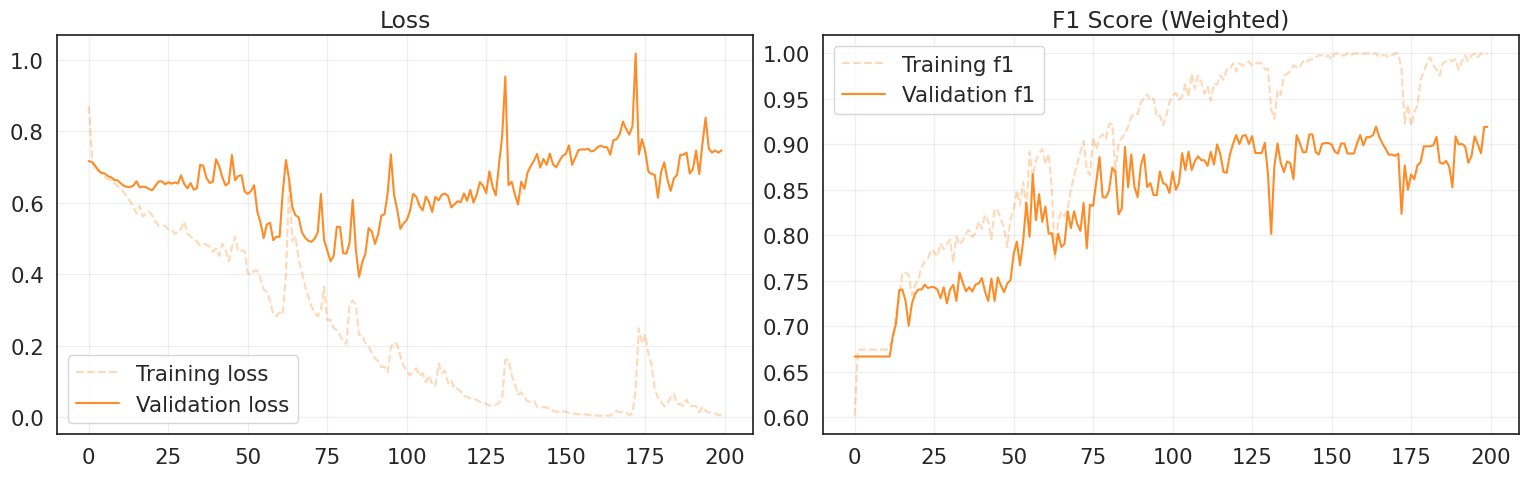

Correct predictions: 86/99  (86.87% accuracy)

Classification report:
              precision    recall  f1-score   support

     no_pain       0.92      0.95      0.94        77
    low_pain       0.71      0.71      0.71        14
   high_pain       0.50      0.38      0.43         8

    accuracy                           0.87        99
   macro avg       0.71      0.68      0.69        99
weighted avg       0.86      0.87      0.86        99

Confusion matrix:
[[73  3  1]
 [ 2 10  2]
 [ 4  1  3]]


In [ ]:

# Plotting History and Test Evaluation


# --- Plotting Training History ---
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

# Plot Loss
ax1.plot(training_history['train_loss'], label='Training loss', alpha=0.3, color='#ff7f0e', linestyle='--')
ax1.plot(training_history['val_loss'], label='Validation loss', alpha=0.9, color='#ff7f0e')
ax1.set_title('Loss')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot F1 Score
ax2.plot(training_history['train_f1'], label='Training f1', alpha=0.3, color='#ff7f0e', linestyle='--')
ax2.plot(training_history['val_f1'], label='Validation f1', alpha=0.9, color='#ff7f0e')
ax2.set_title('F1 Score (Weighted)')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()

# --- Evaluation Function on Test Set ---
def evaluate_on_test(model, test_loader, device, class_names=None):
    """Evaluates model performance on the test set and prints metrics."""
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device).float()
            y_batch = y_batch.to(device).long()
            logits = model(x_batch)
            preds = torch.argmax(logits, dim=1)
            all_preds.append(preds.cpu())
            all_targets.append(y_batch.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()

    correct = (all_preds == all_targets).sum()
    total = len(all_targets)
    acc = correct / total

    print(f"Correct predictions: {correct}/{total}  ({acc:.2%} accuracy)")
    print("\nClassification report:")
    print(classification_report(all_targets, all_preds, target_names=class_names))
    print("Confusion matrix:")
    print(confusion_matrix(all_targets, all_preds))

    return all_preds, all_targets, acc

# Run evaluation on the Test set (using pre-windowed data)
best_model.to(device)
best_model.eval()
class_names = ["no_pain", "low_pain", "high_pain"]

test_preds, test_true, test_acc = evaluate_on_test(
    best_model,
    test_loader,
    device,
    class_names=class_names
)

In [ ]:



# --- Helper Functions for Test Data Preprocessing and Submission ---

def scale_test(df, current_dir):
    """Applies Min-Max scaling using parameters (min/range) calculated from the training set."""
    # Define fixed path for normalization file (relative to current_dir)
    norm_path = os.path.join(current_dir, "code", "normalization.json")

    with open(norm_path, "r") as f:
        norm_info = json.load(f)

    scale_columns = norm_info["scale_columns"]
    mins = pd.Series(norm_info["mins"])
    ranges = pd.Series(norm_info["ranges"])

    df[scale_columns] = (df[scale_columns] - mins) / ranges
    return df

def preprocess_samples(file_path, current_dir):
    """
    Loads raw test data, performs feature engineering, scaling, and generates
    a single sequence (160xN_features) for each unique subject.
    """
    df = pd.read_csv(file_path, header=0)

    print(f"\nProcessing test file: {file_path}")
    print("Pirates (unique samples):", len(np.unique(df['sample_index'])))

    # Convert to float32
    df[df.select_dtypes(include=[np.number]).columns] = df.select_dtypes(include=[np.number]).astype(np.float32)

    # Feature Engineering (same as training)
    df[["n_legs","n_hands","n_eyes"]] = (
        df[["n_legs","n_hands","n_eyes"]]
          .apply(lambda s: s.astype(str).str.strip().str.lower())
    )
    count_map = {"two": 2, "one+peg_leg": 1, "one+hook_hand": 1, "one+eye_patch": 1}
    df["legs_count"]  = df["n_legs"].map(count_map).astype("float32")
    df["hands_count"] = df["n_hands"].map(count_map).astype("float32")
    df["eyes_count"]  = df["n_eyes"].map(count_map).astype("float32")
    df["leg_prosthetic"] = (df["n_legs"]  != "two").astype("float32")
    df["hand_hook"]      = (df["n_hands"] != "two").astype("float32")
    df["eye_patch"]      = (df["n_eyes"]  != "two").astype("float32")
    df_enc = df.drop(columns=["n_legs","n_hands","n_eyes"])

    # Apply scaling
    df_scaled = scale_test(df_enc, current_dir)

    # Load feature columns list
    feature_cols_path = os.path.join(current_dir, 'code', "feature_cols.json")
    with open(feature_cols_path, "r") as f:
        feature_cols = json.load(f)["feature_cols"]

    df_test = df_scaled.sort_values(["sample_index", "time"])
    groups = df_test.groupby("sample_index")

    X_test_final = []
    sample_ids = []

    # Generate one sequence (160 timestamps) per subject
    for pid, g in groups:
        X = g[feature_cols].to_numpy(dtype=np.float32)
        current_len = X.shape[0]

        # Padding/Truncation to match WINDOW_SIZE (160)
        if current_len < WINDOW_SIZE:
            pad_len = WINDOW_SIZE - current_len
            pad_block = np.full((pad_len, X.shape[1]), 0.0, dtype=np.float32)
            X = np.vstack([X, pad_block])
        elif current_len > WINDOW_SIZE:
            # Truncate by taking the last WINDOW_SIZE samples
            X = X[-WINDOW_SIZE:]

        X_test_final.append(X)
        sample_ids.append(pid)

    X_test_final = np.asarray(X_test_final, dtype=np.float32)
    sample_ids = np.asarray(sample_ids)
    print("X_test (final submission) shape:", X_test_final.shape)
    return X_test_final, sample_ids

def predict(model, test_loader, device):
    """Uses the trained model to get class indices for the final test set."""
    model.eval()
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for batch in test_loader:
            # batch is a tuple containing only features (X_test_tensor)
            xb = batch[0].to(device).float()
            logits = model(xb)
            probs = torch.softmax(logits, dim=1)
            preds = probs.argmax(dim=1)

            all_preds.append(preds.cpu().numpy())
            all_probs.append(probs.cpu().numpy())

    all_preds = np.concatenate(all_preds, axis=0)
    all_probs = np.concatenate(all_probs, axis=0)
    return all_preds, all_probs

def submit(indexes, labels, key):
    """Generates the submission CSV file."""
    submission = pd.DataFrame({"sample_index": indexes, "label": labels})
    submission = submission.sort_values("sample_index")
    # Format sample_index to '001', '002', etc.
    submission["sample_index"] = submission["sample_index"].map(lambda x: f"{int(x):03d}")
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    path = f"submission_{key}_{timestamp}.csv"
    submission.to_csv(path, index=False)
    print(submission.head())
    print(f"Saved submission to: {path}")

# --- Final Prediction and Submission ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Process the external test file
test_file_path = "pirate_pain_test.csv"
X_test_submission, sample_ids = preprocess_samples(test_file_path, current_dir)

# Convert to tensors
X_test_tensor = torch.from_numpy(X_test_submission).float()

# Create DataLoader for prediction
test_ds = TensorDataset(X_test_tensor)
# A custom loader is defined here for clarity, using the batch size from training
def make_loader_pred(ds, batch_size, shuffle, drop_last):
    cpu_cores = os.cpu_count() or 2
    num_workers = max(2, min(4, cpu_cores))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last,
                      num_workers=num_workers, pin_memory=True,
                      pin_memory_device="cuda" if torch.cuda.is_available() else "", prefetch_factor=4)

test_loader_final = make_loader_pred(test_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)





Processing test file: pirate_pain_test.csv
Pirates (unique samples): 1324
X_test (final submission) shape: (1324, 160, 41)


In [ ]:
# Use the 'best_model' instance (Bi-GRU)
models_to_submit = {"gru_model": best_model}
class_order = ["no_pain", "low_pain", "high_pain"]
idx_to_label = {i: name for i, name in enumerate(class_order)}

for key, model in models_to_submit.items():
  # Transfer model to the correct device and set to eval mode
  model.to(device)
  model.eval()

  test_pred_indeces, test_pred_probs = predict(model, test_loader_final, device)
  predicted_labels = [idx_to_label[i] for i in test_pred_indeces]

  # Generate submission file
  submit(sample_ids, predicted_labels, key)

  sample_index    label
0          000  no_pain
1          001  no_pain
2          002  no_pain
3          003  no_pain
4          004  no_pain
Saved submission to: submission_gru_model_20251115_084154.csv


# Grid Search

In [ ]:
# fit

def fit_tune(model, train_loader, val_loader, epochs, criterion, optimizer, scaler, device,
        l1_lambda=0, l2_lambda=0, patience=0, evaluation_metric="val_f1", mode='max',
        restore_best_weights=True, writer=None, verbose=10, experiment_name=""):

    training_history = {
        'train_loss': [], 'val_loss': [],
        'train_f1': [], 'val_f1': []
    }

    if patience > 0:
        patience_counter = 0
        best_metric = float('-inf') if mode == 'max' else float('inf')
        best_epoch = 0

    print(f"Training {epochs} epochs...")

    for epoch in range(1, epochs + 1):
        train_loss, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, device, l1_lambda, l2_lambda
        )
        val_loss, val_f1 = validate_one_epoch(
            model, val_loader, criterion, device
        )

        training_history['train_loss'].append(train_loss)
        training_history['val_loss'].append(val_loss)
        training_history['train_f1'].append(train_f1)
        training_history['val_f1'].append(val_f1)

        if scheduler is not None:

            scheduler.step(val_loss)

        if writer is not None:
            log_metrics_to_tensorboard(
                writer, epoch, train_loss, train_f1, val_loss, val_f1, model
            )

        if verbose > 0:
            if epoch % verbose == 0 or epoch == 1:
                current_lr = optimizer.param_groups[0]['lr']
                print(f"Epoch {epoch:3d}/{epochs} | LR={current_lr:.6f} | "
                    f"Train: Loss={train_loss:.4f}, F1 Score={train_f1:.4f} | "
                    f"Val: Loss={val_loss:.4f}, F1 Score={val_f1:.4f}")

        if patience > 0:
            current_metric = training_history[evaluation_metric][-1]
            is_improvement = (current_metric > best_metric) if mode == 'max' else (current_metric < best_metric)

            if is_improvement:
                best_metric = current_metric
                best_epoch = epoch
                # Save the model state dict locally
                torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping triggered after {epoch} epochs.")
                    break

    if restore_best_weights and patience > 0:
        model.load_state_dict(torch.load("models/"+experiment_name+'_model.pt'))
        print(f"Best model restored from epoch {best_epoch} with {evaluation_metric} {best_metric:.4f}")

    if patience == 0:
        torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')

    if writer is not None:
        writer.close()

    return model, training_history

In [ ]:
from itertools import product
from torch.optim.lr_scheduler import ReduceLROnPlateau
import copy

In [ ]:
#  Grid Search Loop for Fine-Tuning ---
print("\n" * 3 + "=" * 80)
print("START GRID SEARCH")
print("=" * 80 + "\n")

best_model_overall = None
best_performance_overall = float('-inf')

#  Bidirectional GRU
FIXED_PARAMS = {
    'rnn_type': 'GRU',
    'bidirectional': True,
}

# Parametrs for  Grid Search
search_space = {
    'hidden_size': [128,256],
    'num_layers': [2,3],
    'dropout_rate': [0.1,0.2,0.4],
}

LEARNING_RATE = 1e-3
EPOCHS = 200
PATIENCE = 100 # Early stopping patience
HIDDEN_LAYERS = 2
HIDDEN_SIZE = 128
DROPOUT_RATE = 0.2
L2_LAMBDA = 0

#  Loss Function
criterion = nn.CrossEntropyLoss()

# directory for models
os.makedirs("models", exist_ok=True)


all_results = []
counter = 0
keys = search_space.keys()
values = search_space.values()

num_combinations = len(list(product(*values)))
print(f"Start Grid Search with {num_combinations} combinations (GRU Bidirezional fixed).")

for hyperparams_tuple in product(*values):
    current_params = FIXED_PARAMS.copy()
    current_params.update(dict(zip(keys, hyperparams_tuple)))

    counter += 1

    exp_name = (
        f"run_{counter}_bi_GRU_h{current_params['hidden_size']}_l{current_params['num_layers']}_d{current_params['dropout_rate']}"
        .replace('.', '_')
    )

    print("=" * 60)
    print(f"Inizio Esperimento {counter}: {exp_name}")
    for k, v in current_params.items():
        print(f"  {k}: {v}")
    print("-" * 60)

    # 1. model
    current_model = RecurrentClassifier(
        input_size=input_shape[-1],
        hidden_size=current_params['hidden_size'],
        num_layers=current_params['num_layers'],
        num_classes=num_classes,
        dropout_rate=current_params['dropout_rate'],
        bidirectional=current_params['bidirectional'],
        rnn_type=current_params['rnn_type']
    ).to(device)

    # 2. optimizer
    current_optimizer = torch.optim.AdamW(
        current_model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=0.0
    )
    current_scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))


    scheduler=None #i tried a scheduler for the learning rate but it didn't imporve performance

    # 4. TensorBoard
    writer = SummaryWriter("./" + logs_dir + "/" + exp_name)
    x_dummy = torch.randn(1, input_shape[0], input_shape[1]).to(device)

    print("\nModel architecture:")
    recurrent_summary(current_model, input_size=input_shape)
    print("-" * 60)

    # 5. Train the model (fit_tune function should be defined in a previous cell)
    current_model, history = fit_tune(
        model=current_model,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=EPOCHS,
        criterion=criterion,
        optimizer=current_optimizer,
        scaler=current_scaler,
        device=device,
        writer=writer,
        verbose=10,
        experiment_name=exp_name,
        patience=PATIENCE,

    )

    # 6. Register the result
    final_val_f1 = validate_one_epoch(current_model, val_loader, criterion, device)[1]

    all_results.append({
        'experiment': exp_name,
        'params': current_params,
        'best_val_f1': final_val_f1
    })

    # 7. Check for overall best model
    if final_val_f1 > best_performance_overall:
        best_performance_overall = final_val_f1
        best_model_overall = copy.deepcopy(current_model)
        print(f"\nNEW BEST MODEL GLOBAL: F1={best_performance_overall:.4f} per {exp_name}")

print("\n\n=== Final results  Grid Search ===")
results_df = pd.DataFrame(all_results).sort_values(by='best_val_f1', ascending=False)
print(results_df)

# best model = rnn_model
if best_model_overall is not None:
    # rnn_model will be used in the final evaluation cell
    rnn_model = best_model_overall
    print("\nVariabile 'rnn_model' updated with best Grid Search.")




START GRID SEARCH

Start Grid Search with 12 combinations (GRU Bidirezional fixed).
Inizio Esperimento 1: run_1_bi_GRU_h128_l2_d0_1
  rnn_type: GRU
  bidirectional: True
  hidden_size: 128
  num_layers: 2
  dropout_rate: 0.1
------------------------------------------------------------

Model architecture:
-------------------------------------------------------------------------------
Layer (type)              Output Shape                 Param #           
rnn (GRU)                 [[-1, 160, 256], [4, -1, 128]] 427,776        
classifier (Linear)       [-1, 3]                      771            
Total params: 428,547
Trainable params: 428,547
Non-trainable params: 0
-------------------------------------------------------------------------------
------------------------------------------------------------
Training 200 epochs...
Epoch   1/200 | LR=0.001000 | Train: Loss=0.8713, F1 Score=0.5755 | Val: Loss=0.7164, F1 Score=0.6668
Epoch  10/200 | LR=0.001000 | Train: Loss=0.6355, F1 S

In [ ]:
# Save the state dictionary of the overall best model found during the Grid Search

if best_model_overall is not None:
    # saved in:
    BEST_MODEL_PATH = "models/best_GRU_grid_search.pt"

    # saved weights
    torch.save(best_model_overall.state_dict(), BEST_MODEL_PATH)

    print("=" * 60)
    print(f"Best model saved in : {BEST_MODEL_PATH}")
    print(f"Performance (Val F1) : {best_performance_overall:.4f}")
    print("=" * 60)
else:
    print("No model can be saved.")

Best model saved in : models/best_GRU_grid_search.pt
Performance (Val F1) : 0.9179


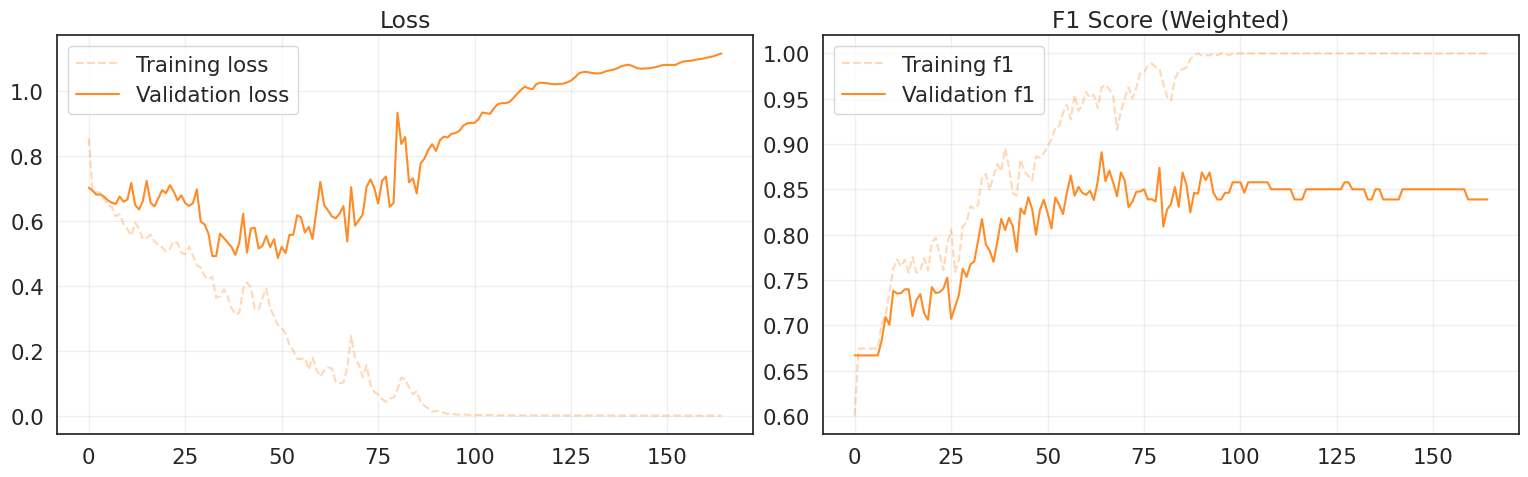

Correct predictions: 85/99  (85.86% accuracy)

Classification report:
              precision    recall  f1-score   support

     no_pain       0.92      0.94      0.93        77
    low_pain       0.65      0.79      0.71        14
   high_pain       0.50      0.25      0.33         8

    accuracy                           0.86        99
   macro avg       0.69      0.66      0.66        99
weighted avg       0.85      0.86      0.85        99

Confusion matrix:
[[72  4  1]
 [ 2 11  1]
 [ 4  2  2]]


In [ ]:
### Cell 10: Plotting History and Test Evaluation


# --- Plotting Training History ---
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

# Plot Loss
ax1.plot(history['train_loss'], label='Training loss', alpha=0.3, color='#ff7f0e', linestyle='--')
ax1.plot(history['val_loss'], label='Validation loss', alpha=0.9, color='#ff7f0e')
ax1.set_title('Loss')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot F1 Score
ax2.plot(history['train_f1'], label='Training f1', alpha=0.3, color='#ff7f0e', linestyle='--')
ax2.plot(history['val_f1'], label='Validation f1', alpha=0.9, color='#ff7f0e')
ax2.set_title('F1 Score (Weighted)')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()

# --- Evaluation Function on Test Set ---
def evaluate_on_test(model, test_loader, device, class_names=None):
    """Evaluates model performance on the test set and prints metrics."""
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device).float()
            y_batch = y_batch.to(device).long()
            logits = model(x_batch)
            preds = torch.argmax(logits, dim=1)
            all_preds.append(preds.cpu())
            all_targets.append(y_batch.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()

    correct = (all_preds == all_targets).sum()
    total = len(all_targets)
    acc = correct / total

    print(f"Correct predictions: {correct}/{total}  ({acc:.2%} accuracy)")
    print("\nClassification report:")
    print(classification_report(all_targets, all_preds, target_names=class_names))
    print("Confusion matrix:")
    print(confusion_matrix(all_targets, all_preds))

    return all_preds, all_targets, acc

# Run evaluation on the Test set (using pre-windowed data)
best_model_overall.to(device)
best_model_overall.eval()
class_names = ["no_pain", "low_pain", "high_pain"]

test_preds, test_true, test_acc = evaluate_on_test(
    best_model_overall,
    test_loader,
    device,
    class_names=class_names
)

In [ ]:
models_to_submit = {"rnn_model": best_model_overall}
class_order = ["no_pain", "low_pain", "high_pain"]
idx_to_label = {i: name for i, name in enumerate(class_order)}

for key, model in models_to_submit.items():
  # Transfer model to the correct device and set to eval mode
  model.to(device)
  model.eval()

  test_pred_indeces, test_pred_probs = predict(model, test_loader_final, device)
  predicted_labels = [idx_to_label[i] for i in test_pred_indeces]

  # Generate submission file
  submit(sample_ids, predicted_labels, key)

  sample_index    label
0          000  no_pain
1          001  no_pain
2          002  no_pain
3          003  no_pain
4          004  no_pain
Saved submission to: submission_rnn_model_20251115_114427.csv
